# 3D - Rigor: o que sobrevive estatisticamente?

**Pergunta especifica.** Quais relacoes defasadas do 3C sobrevivem a graus de liberdade efetivos (N_eff), FDR e IC95 que exclua zero?

**Objetivo.** Converter a triagem do 3C em conjunto defensavel, com N_eff/p/q/IC95 por par (variavel, lag).

**Justificativa.** A memoria de ~6 meses (3B) reduz N_eff de ~1740 para ~25; a varredura de 78 lags x 8 variaveis exige FDR. Sem isso, dezenas de falsos positivos.

**Metodologia.** Por par (variavel, lag) em 1993+: N_eff (Bretherton), p efetivo, IC95 Fisher-z; FDR Benjamini-Hochberg (alpha=0.05). Sobrevive = FDR-sig E IC95 exclui zero.

**Saidas.** `phase3D_testes_completos.csv`, `phase3D_ranking_significativo.csv`, forest plot IC95, mapa lon x lag mascarado por FDR.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value, benjamini_hochberg_fdr
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday').loc['1993-01-01':]
tgt=w['nino34_ssta']; rows=[]
for v in [c for c in w.columns if c!='nino34_ssta']:
    for lag in range(0,79):
        x=w[v].shift(lag); m=x.notna()&tgt.notna()
        if m.sum()<100: continue
        r=float(np.corrcoef(x[m],tgt[m])[0,1]); neff=effective_sample_size(x[m].values,tgt[m].values)
        z=np.arctanh(np.clip(r,-.999999,.999999)); se=1/np.sqrt(max(neff-3,1))
        rows.append(dict(variavel=v,lag_semanas=lag,r=r,n=int(m.sum()),n_eff=round(float(neff),1),p_efetivo=correlation_p_value(r,neff),ic95_low=float(np.tanh(z-1.96*se)),ic95_high=float(np.tanh(z+1.96*se))))
t=pd.DataFrame(rows); rej,q=benjamini_hochberg_fdr(t['p_efetivo'].values,0.05); t['fdr_significativo']=rej; t['q_valor']=q
t['sobrevive']=t['fdr_significativo']&((t['ic95_low']>0)|(t['ic95_high']<0))
t.round(4).to_csv(u.STATS/'phase3D_testes_completos.csv',index=False)
print(f'{len(t)} testes | sobreviventes FDR+IC95: {int(t.sobrevive.sum())}')

632 testes | sobreviventes FDR+IC95: 229


In [2]:
surv=t[t['sobrevive']]; best=surv.loc[surv.groupby('variavel')['r'].apply(lambda s:s.abs().idxmax())].sort_values('r',key=abs,ascending=False).set_index('variavel')
u.save_table(best.round(4),'phase3D_ranking_significativo.csv')
print('SOBREVIVENTES (variavel | lag | r | N_eff caiu de ~%d):'%int(t['n'].median()))
for v,rr in best.iterrows(): print(f'  {v:22s} lag {int(rr.lag_semanas):2d}  r={rr.r:+.3f}  N_eff={rr.n_eff:.0f}  q={rr.q_valor:.3f}')

[tabela] data\processed\parquet\statistics\phase3D_ranking_significativo.csv
SOBREVIVENTES (variavel | lag | r | N_eff caiu de ~1707):
  tilt_m                 lag  0  r=+0.772  N_eff=26  q=0.000
  ssh_m                  lag  6  r=+0.755  N_eff=33  q=0.000
  ohc_0_300              lag  6  r=+0.738  N_eff=30  q=0.000
  ohc_0_700              lag  6  r=+0.701  N_eff=32  q=0.000
  dhw_cweek_p90          lag  0  r=+0.600  N_eff=22  q=0.013
  d20_m                  lag 15  r=+0.545  N_eff=30  q=0.008
  wwv                    lag 20  r=+0.516  N_eff=24  q=0.030
  tau_x_anom_nino34_pa   lag  1  r=+0.478  N_eff=468  q=0.000


[figura] data\processed\figures\fase3\phase3D_forest_ic95.png


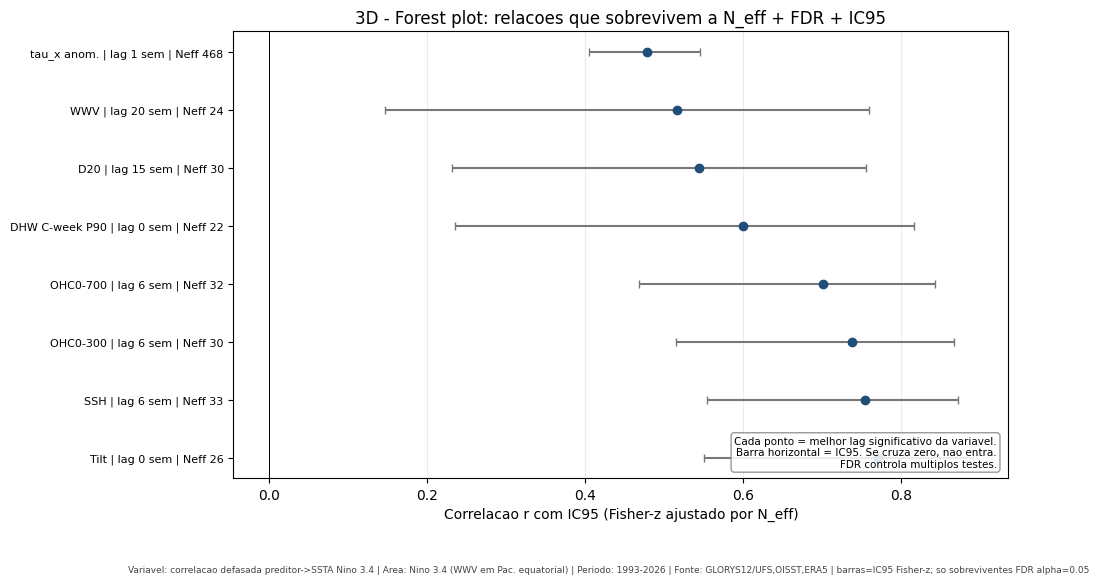

In [3]:
bb=best.reset_index().copy()
bb['label']=[f"{u.var_label(v, short=True)} | lag {int(l)} sem | Neff {n:.0f}" for v,l,n in zip(bb['variavel'],bb['lag_semanas'],bb['n_eff'])]
fig,ax=plt.subplots(figsize=(10,5.8))
y=np.arange(len(bb))
ax.errorbar(bb['r'],y,xerr=[bb['r']-bb['ic95_low'],bb['ic95_high']-bb['r']],fmt='o',color='#1f4e79',ecolor='#777',capsize=3)
ax.set_yticks(y); ax.set_yticklabels(bb['label'],fontsize=8)
ax.axvline(0,color='k',lw=.7); ax.grid(axis='x',alpha=.25)
ax.set_xlabel('Correlacao r com IC95 (Fisher-z ajustado por N_eff)')
ax.set_title('3D - Forest plot: relacoes que sobrevivem a N_eff + FDR + IC95')
u.add_note(ax,'Cada ponto = melhor lag significativo da variavel.\nBarra horizontal = IC95. Se cruza zero, nao entra.\nFDR controla multiplos testes.',loc='lower right')
u.stamp_caption(fig,variavel='correlacao defasada preditor->SSTA Nino 3.4',area='Nino 3.4 (WWV em Pac. equatorial)',periodo='1993-2026',fonte='GLORYS12/UFS,OISST,ERA5',extra='barras=IC95 Fisher-z; so sobreviventes FDR alpha=0.05')
u.save_fig(fig,'phase3D_forest_ic95.png'); plt.show()


[tabela] data\processed\parquet\statistics\phase3D_mapa_fdr_resumo.csv


[figura] data\processed\figures\fase3\phase3D_mapa_lon_lag_fdr.png


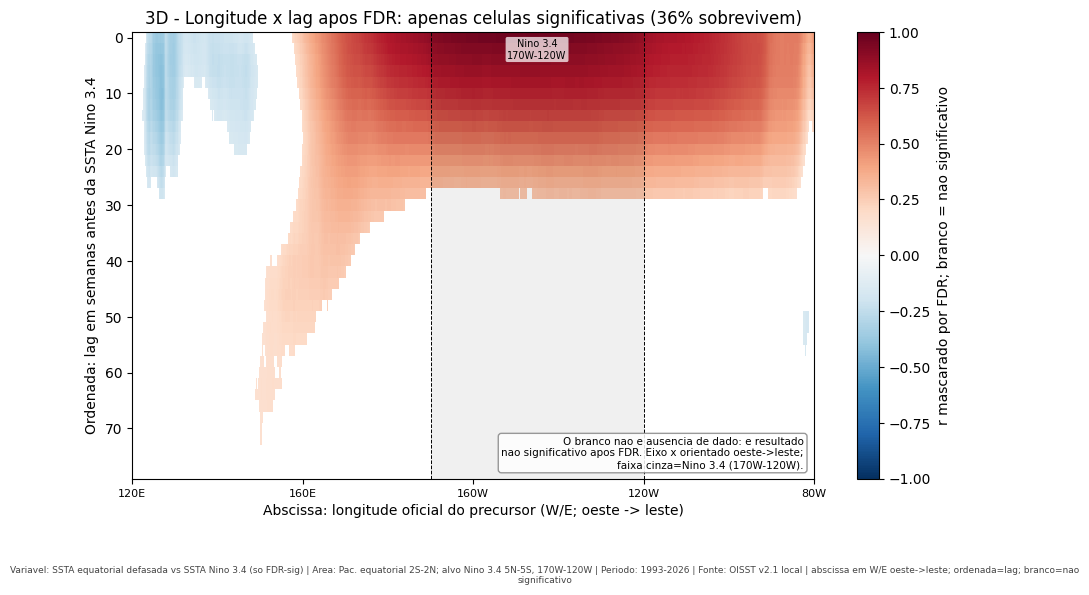

In [4]:
eq=u.load_eqband_weekly().loc['1993-01-01':]; eqa,ta=eq.align(tgt,join='inner',axis=0); tv=ta.values; lags=list(range(0,79,2))
R=np.full((len(lags),eqa.shape[1]),np.nan); P=np.full_like(R,np.nan)
for i,lag in enumerate(lags):
    sh=eqa.shift(lag).values
    for j in range(eqa.shape[1]):
        x=sh[:,j]; m=np.isfinite(x)&np.isfinite(tv)
        if m.sum()>100:
            r=float(np.corrcoef(x[m],tv[m])[0,1]); R[i,j]=r; P[i,j]=correlation_p_value(r,effective_sample_size(x[m],tv[m]))
flat=P[np.isfinite(P)]; rej,_=benjamini_hochberg_fdr(flat,0.05); pcrit=float(flat[rej].max()) if rej.any() else float('nan')
mask=np.full_like(P,False,dtype=bool); mask[np.isfinite(P)]=rej; Rm=np.where(mask,R,np.nan); lon=eqa.columns.values
fig,ax=plt.subplots(figsize=(11,5.8))
pc=ax.pcolormesh(lon,lags,Rm,cmap='RdBu_r',vmin=-1,vmax=1,shading='auto')
u.add_nino34_lon_band(ax)
u.format_lon_axis(ax, xlabel='Abscissa: longitude oficial do precursor (W/E; oeste -> leste)')
ax.invert_yaxis(); ax.set_ylabel('Ordenada: lag em semanas antes da SSTA Nino 3.4')
pct=100*mask.sum()/np.isfinite(P).sum()
ax.set_title(f'3D - Longitude x lag apos FDR: apenas celulas significativas ({pct:.0f}% sobrevivem)')
fig.colorbar(pc,ax=ax,label='r mascarado por FDR; branco = nao significativo')
u.add_note(ax,'O branco nao e ausencia de dado: e resultado\nnao significativo apos FDR. Eixo x orientado oeste->leste;\nfaixa cinza=Nino 3.4 (170W-120W).',loc='lower right')
u.stamp_caption(fig,variavel='SSTA equatorial defasada vs SSTA Nino 3.4 (so FDR-sig)',area='Pac. equatorial 2S-2N; alvo Nino 3.4 5N-5S, 170W-120W',periodo='1993-2026',fonte='OISST v2.1 local',extra='abscissa em W/E oeste->leste; ordenada=lag; branco=nao significativo')
u.save_table(pd.DataFrame({'metrica':['testes_validos','sobreviventes_fdr','pct','p_critico'],'valor':[int(np.isfinite(P).sum()),int(mask.sum()),round(pct,1),pcrit]}),'phase3D_mapa_fdr_resumo.csv',index=False)
u.save_fig(fig,'phase3D_mapa_lon_lag_fdr.png'); plt.show()


**Leitura do 3D.** A correcao por N_eff e severa: o N nominal ~1740 vira N_eff ~22-33 (a memoria de 6 meses do 3B "consome" graus de liberdade). Ainda assim sobrevivem, com sinal claro: **tilt (r=0.77, lag0), SSH/OHC 0-300/0-700 (~6 sem), DHW (lag0), D20 (15 sem), WWV (20 sem), tau_x_anom (lag1)**. Tudo Pacifico. O que entra no parecer depende ainda da estabilidade (3E).